In [3]:
import numpy as np, pandas as pd, pathlib as pl

np.random.seed(42)
n = 500

df = pd.DataFrame({
    "date": pd.date_range("2023-01-01", periods=n, freq="D"),
    "sector": np.random.choice(["Banks","Energy","Tech","Retail"], size=n, p=[0.3,0.2,0.3,0.2]),
    "region": np.random.choice(["US","EU","APAC"], size=n),
    "revenue": np.random.lognormal(mean=10, sigma=0.4, size=n),
    "risk_score": np.clip(np.random.normal(loc=50, scale=12, size=n), 0, 100),
    "n_clients": np.random.poisson(lam=20, size=n)
})
# sprinkle missing values
for col in ["sector","region","revenue","risk_score"]:
    df.loc[np.random.choice(df.index, size=30, replace=False), col] = np.nan

# save to processed
PRO = pl.Path("../data/processed"); PRO.mkdir(parents=True, exist_ok=True)
out = PRO / "homework_eda_sample.parquet"
df.to_parquet(out, index=False)
print("Saved sample dataset:", out.resolve())


Saved sample dataset: C:\Users\User\bootcamp_Khushi_Khanna\homework\homework8\data\processed\homework_eda_sample.parquet


In [5]:
import os, pathlib as pl
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 100)

DATA_DIR_PROCESSED = "../data/processed"
PRO = pl.Path(DATA_DIR_PROCESSED)

cands = list(PRO.glob("*.parquet")) + list(PRO.glob("*.csv"))
assert cands, f"No files found in {PRO.resolve()}. Put a processed dataset there or generate a sample."

latest = max(cands, key=lambda p: p.stat().st_mtime)
if latest.suffix.lower() == ".parquet":
    df = pd.read_parquet(latest)
else:
    df = pd.read_csv(latest)

print(f"Loaded: {latest.name}  | shape: {df.shape}")
df.head(3)


Loaded: homework_eda_sample.parquet  | shape: (500, 6)


,date,sector,region,revenue,risk_score,n_clients
0,2023-01-01,Energy,EU,17409.394782,65.477078,24
1,2023-01-02,Retail,APAC,20881.933888,46.863201,22
2,2023-01-03,Tech,US,33806.169246,51.446000,19


In [6]:
df.info()
df.isna().sum().sort_values(ascending=False).head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        500 non-null    datetime64[ns]
 1   sector      470 non-null    object        
 2   region      470 non-null    object        
 3   revenue     470 non-null    float64       
 4   risk_score  470 non-null    float64       
 5   n_clients   500 non-null    int32         
dtypes: datetime64[ns](1), float64(2), int32(1), object(2)
memory usage: 21.6+ KB


sector        30
region        30
risk_score    30
revenue       30
date           0
n_clients      0
dtype: int64

In [7]:
print("Shape:", df.shape)
print("\nColumn names:", list(df.columns))

# dtypes
print("\nDtypes:")
display(df.dtypes)

# missing values (top 15)
print("\nMissing values (top 15):")
display(df.isna().sum().sort_values(ascending=False).head(15))

# numeric summary
print("\nNumeric summary:")
display(df.describe().T)

# quick categorical peek (top 10 categories for up to 5 columns)
cat_cols = [c for c in df.columns if df[c].dtype == "object"]
for c in cat_cols[:5]:
    print(f"\nTop values in '{c}':")
    display(df[c].value_counts(dropna=False).head(10))


Shape: (500, 6)

Column names: ['date', 'sector', 'region', 'revenue', 'risk_score', 'n_clients']

Dtypes:


date          datetime64[ns]
sector                object
region                object
revenue              float64
risk_score           float64
n_clients              int32
dtype: object


Missing values (top 15):


sector        30
region        30
risk_score    30
revenue       30
date           0
n_clients      0
dtype: int64


Numeric summary:


,count,mean,min,25%,50%,75%,max,std
date,500,2023-09-07 12:00:00,2023-01-01 00:00:00,2023-05-05 18:00:00,2023-09-07 12:00:00,2024-01-10 06:00:00,2024-05-14 00:00:00,NaN
revenue,470.0,23598.852953,5473.516004,16733.634127,21927.290936,28304.422247,72114.047704,9677.610844
risk_score,470.0,49.572644,15.340746,41.307519,49.701045,57.108033,81.958188,11.965462
n_clients,500.0,20.116,8.0,17.0,20.0,23.0,35.0,4.769491



Top values in 'sector':


sector
Banks     146
Tech      145
Retail     95
Energy     84
None       30
Name: count, dtype: int64


Top values in 'region':


region
US      159
EU      158
APAC    153
None     30
Name: count, dtype: int64

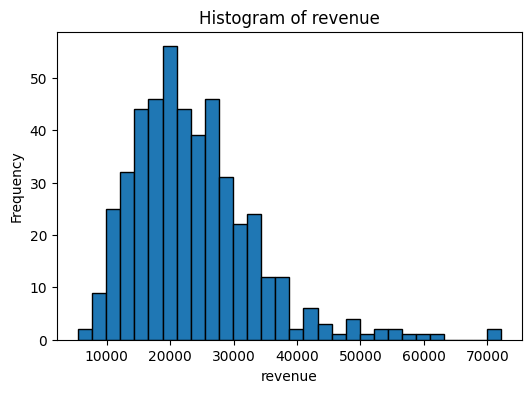

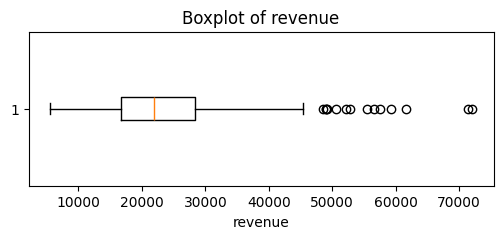

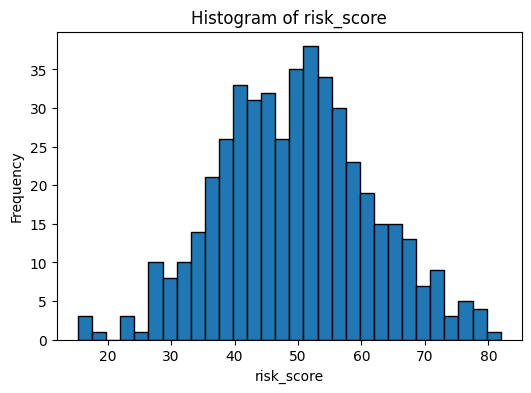

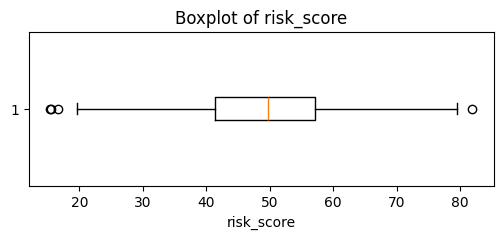

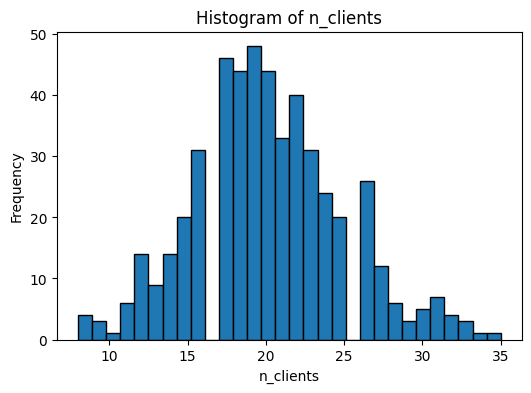

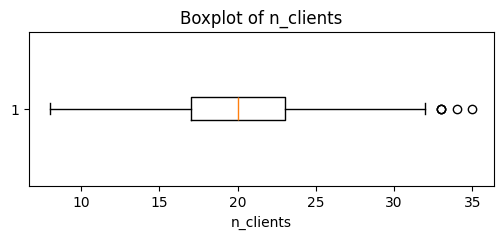

In [9]:
import matplotlib.pyplot as plt

num_cols = ["revenue", "risk_score", "n_clients"]

for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30, edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(6,2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()


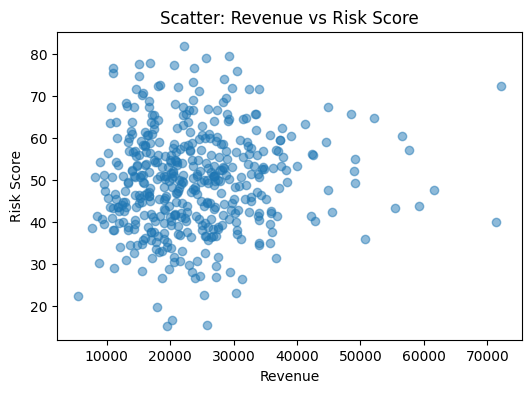

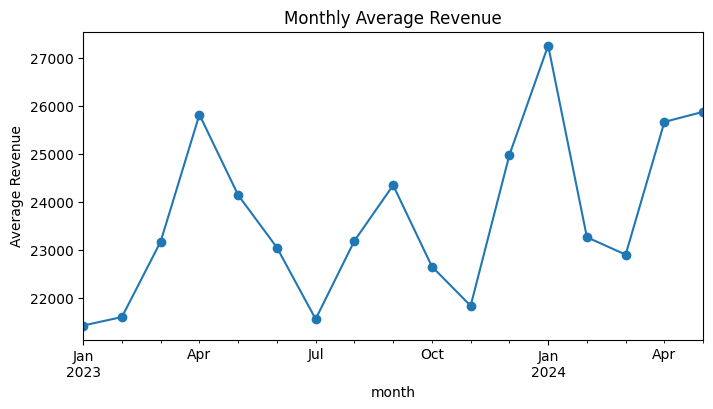

In [10]:
# scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df["revenue"], df["risk_score"], alpha=0.5)
plt.xlabel("Revenue")
plt.ylabel("Risk Score")
plt.title("Scatter: Revenue vs Risk Score")
plt.show()

df["month"] = pd.to_datetime(df["date"]).dt.to_period("M")
monthly_avg = df.groupby("month")["revenue"].mean()

plt.figure(figsize=(8,4))
monthly_avg.plot(marker="o")
plt.ylabel("Average Revenue")
plt.title("Monthly Average Revenue")
plt.show()


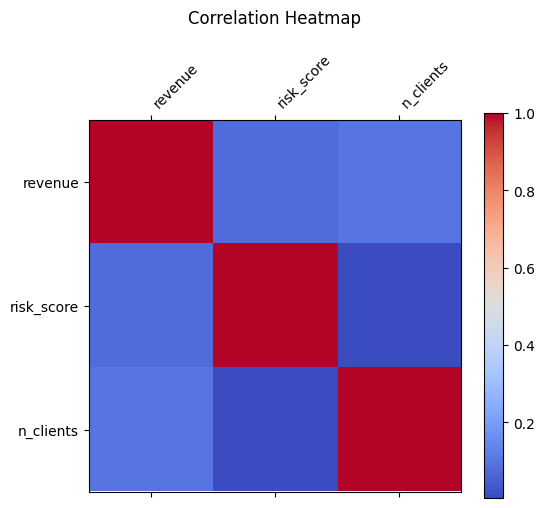

,revenue,risk_score,n_clients
revenue,1.000000,0.076040,0.099678
risk_score,0.076040,1.000000,0.003887
n_clients,0.099678,0.003887,1.000000


In [11]:
import numpy as np

corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(6,5))
cax = ax.matshow(corr, cmap="coolwarm")
plt.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="left")
ax.set_yticklabels(corr.columns)

plt.title("Correlation Heatmap", pad=20)
plt.show()

corr


### Insights
1. Revenue distribution is highly skewed with some major outliers.
2. Risk scores are roughly bell-shaped, most between 30–70.
3. Revenue tends to increase slightly with the no. of clients (positive correlation).

### Assumptions & Risks
- Sample data may not reflect real-world distributions.
- Outliers may distort regression results later.

